# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [1]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
from NM_TinyRNN.code.models import training_fast as speedrun
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import nested_cv_io as save_data
from NM_TinyRNN.code.models import nested_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:

# let's test some code!
test_data_path = DATA_PATH / "WS16"
test_save_path  = './NM_TinyRNN/data/rnns/gpu_test'
reload(save_data)
reload(ds)
reload(nc)
reload(speedrun)
reload(rnns)
trainer = speedrun.TrainerGPU(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1,0.1,1e-2,1e-3,1e-4,1e-5,1e-6],
                        energy_lambdas = [1,0.1,1e-2,1e-3],
                        hebbian_lambdas = [0.0])
model = rnns.TinyRNN(rnn_type = 'vanilla', hidden_size = 2)
dataset = ds.AB_Dataset(test_data_path, sequence_length = 64)

#final_state_dict, config = trainer.fit(model, dataset)


Sequence length 64 excludes 7.1% of trials


In [184]:
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset,splits['inner_folds'][0])
outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 10,
                                  save_path = test_save_path, 
                                  trainer_kwargs = {'sparsity_lambdas':[1e-1,1e-2,1e-3,1e-4,1e-5],
                                                    'energy_lambdas':[0.1,1e-2,1e-3]})
print([d['val_loss'] for d in outer_results['inner_results']])


[outer 1/10]  outer eval: 11 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/gpu_test
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu


 14%|█▍        | 142/1000 [01:05<06:32,  2.19it/s]

Search complete. Best model index: 117. Val. loss: 0.5111628174781799
  Saved outer_fold_1/inner_fold_7 -> NM_TinyRNN/data/rnns/gpu_test/outer_fold_1/inner_fold_7  (val_loss=0.5112, eval_loss=0.6344)
Parallelizing 150 models on cpu


 28%|██▊       | 281/1000 [02:05<05:20,  2.24it/s]


[0.47655779123306274, 0.5073539018630981, 0.48726028203964233, 0.4491475820541382, 0.48639070987701416, 0.4798084795475006, 0.4782405197620392, 0.5111628174781799, 0.4766395092010498]


In [186]:
test_df = nested_jobs.run_training(overwrite=True, test= False)

Submitting model training for WS20 to HPC
Submitted batch job 2766116
Submitting model training for WS20 to HPC
Submitted batch job 2766117
Submitting model training for WS20 to HPC
Submitted batch job 2766118
Submitting model training for WS20 to HPC
Submitted batch job 2766119
Submitting model training for WS20 to HPC
Submitted batch job 2766120
Submitting model training for WS20 to HPC
Submitted batch job 2766121
Submitting model training for WS20 to HPC
Submitted batch job 2766122
Submitting model training for WS20 to HPC
Submitted batch job 2766123
Submitting model training for WS20 to HPC
Submitted batch job 2766124
Submitting model training for WS20 to HPC
Submitted batch job 2766125
Submitting model training for WS20 to HPC
Submitted batch job 2766126
Submitting model training for WS20 to HPC
Submitted batch job 2766127
Submitting model training for WS20 to HPC
Submitted batch job 2766128
Submitting model training for WS20 to HPC
Submitted batch job 2766129
Submitting model tra

## Analysing results



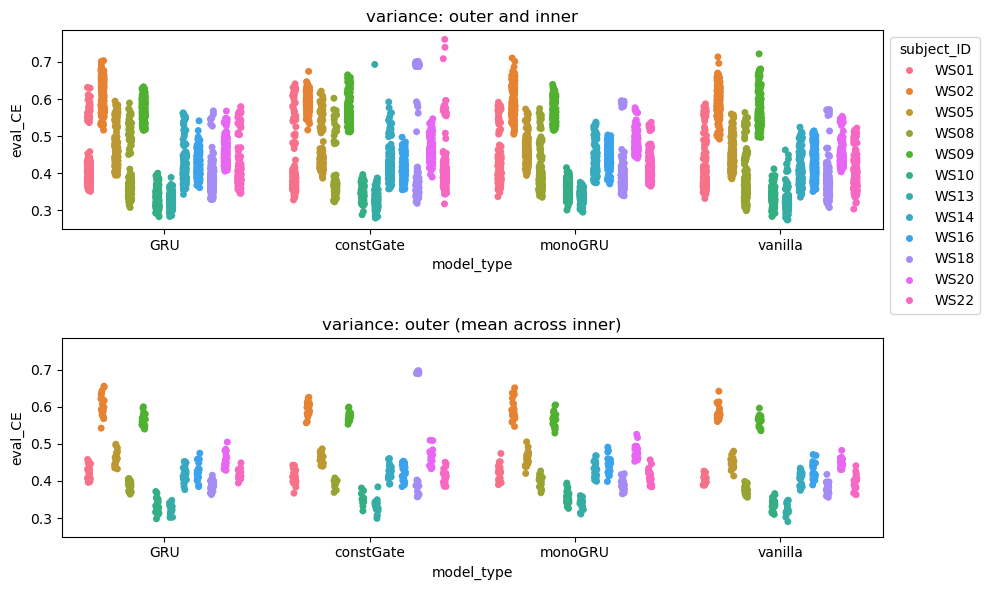

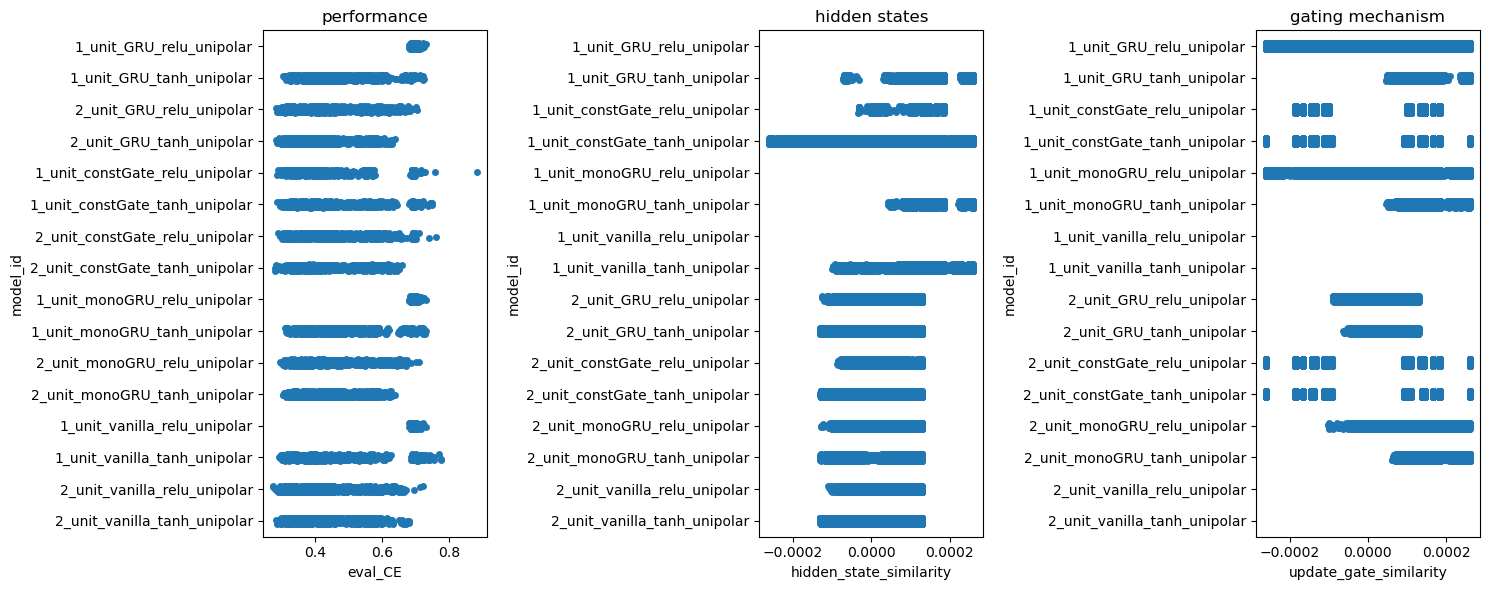

In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

COMPONENTS = ['hidden', 'gate_update', 'gate_reset', 'logit_value']

def compute_similarities(analysis_df, n_jobs=-1):
    """Compute similarity of activations within each (model_id, subject_id) group, in parallel."""
    groups = list(analysis_df.groupby(['model_id', 'subject_ID']))
 
    results = Parallel(n_jobs=n_jobs)(
        delayed(_process_group)(group_rows.reset_index(drop=True), model_id, subject_id)
        for (model_id, subject_id), group_rows in groups
    )
 
    results = [r for r in results if r is not None]
    return pd.DataFrame([row for result in results for row in result]) if results else pd.DataFrame()
 
 
def _process_group(group_rows, model_id, subject_id):
    """
    For a single (model_id, subject_id):
    - Builds a (n_trials, n_outer, n_inner, n_comp) matrix
    - For each component, computes a vectorized (n_outer*n_inner, n_outer*n_inner) Pearson correlation matrix
    - Reads off-diagonal pairs back into rows
    """
    outer_vals = sorted(group_rows['outer_loop_n'].unique())
    inner_vals = sorted(group_rows['inner_loop_idx'].unique())
    n_outer, n_inner = len(outer_vals), len(inner_vals)
    n_folds = n_outer * n_inner
    outer_idx_map = {v: i for i, v in enumerate(outer_vals)}
    inner_idx_map = {v: i for i, v in enumerate(inner_vals)}
 
    # Load and standardize all data into the grid
    loaded = {}
    for _, row in group_rows.iterrows():
        data = analysis.load_data(row.trials_data_path)
        if data is not None:
            loaded[(row.outer_loop_n, row.inner_loop_idx)] = _standardize_hidden_units(data)
 
    if len(loaded) < 2:
        return None
 
    ref_df = next(iter(loaded.values()))
    n_trials = len(ref_df)
 
    # Identify component columns from reference df
    comp_cols = {comp: [c for c in ref_df.columns if c.startswith(comp)] for comp in COMPONENTS}
    all_cols = [c for cols in comp_cols.values() for c in cols]
    col_idx = {c: i for i, c in enumerate(all_cols)}
    n_comp = len(all_cols)
 
    # Build big matrix: (n_trials, n_outer, n_inner, n_comp)
    big_matrix = np.full((n_trials, n_outer, n_inner, n_comp), np.nan)
    for (outer, inner), df in loaded.items():
        oi = outer_idx_map[outer]
        ii = inner_idx_map[inner]
        big_matrix[:, oi, ii, :] = df[all_cols].values
 
    # Flatten (n_outer, n_inner) -> n_folds: (n_trials, n_folds, n_comp)
    # Fold order: outer varies slowest, inner fastest (C-order)
    X = big_matrix.reshape(n_trials, n_folds, n_comp)
 
    # Upper triangle pairs (i < j), maps flat fold index back to (outer, inner)
    fi, fj = np.triu_indices(n_folds, k=1)
    fold_outer = np.array(outer_vals)[np.arange(n_folds) // n_inner]
    fold_inner = np.array(inner_vals)[np.arange(n_folds) % n_inner]
 
    results = []
    for comp, cols in comp_cols.items():
        if not cols:
            continue
        cidx = [col_idx[c] for c in cols]
 
        # Extract component slice: (n_trials, n_folds, n_cidx)
        X_comp = X[:, :, cidx]
 
        # Concatenate component cols along trials axis -> (n_cidx * n_trials, n_folds)
        # For each fold column: [col0_trial0..col0_trialN, col1_trial0..col1_trialN, ...]
        X_comp = X_comp.transpose(2, 0, 1).reshape(-1, n_folds)  # (n_cidx * n_trials, n_folds)
 
        # Pearson r via normalised dot product:
        # subtract column mean, divide by column norm -> each column has mean=0, norm=1
        # then corr(i,j) = col_i · col_j  (no further division needed)
        X_comp = X_comp - np.nanmean(X_comp, axis=0, keepdims=True)
        norms = np.linalg.norm(X_comp, axis=0, keepdims=True)
        norms[norms == 0] = np.nan
        X_comp = X_comp / norms  # each column now unit norm
 
        corr_matrix = X_comp.T @ X_comp  # (n_folds, n_folds) — exact Pearson r
 
        pair_sims = corr_matrix[fi, fj]  # upper triangle, shape (n_pairs,)
 
        for k in range(len(fi)):
            results.append({
                "model_id":       model_id,
                "subject_id":     subject_id,
                "model_A_outer_n": fold_outer[fi[k]],
                "model_A_inner_n": fold_inner[fi[k]],
                "model_B_outer_n": fold_outer[fj[k]],
                "model_B_inner_n": fold_inner[fj[k]],
                "component":      comp,
                "similarity":     pair_sims[k],
            })
 
    return results
 


def _standardize_hidden_units(trials_df: pd.DataFrame, verbose: bool = False):
    """Standardizes a 2-unit network for alignment."""
    if trials_df is None:
        return None

    trials_df = trials_df.copy()

    corr1 = np.corrcoef(trials_df.hidden_1, trials_df.logit_value)[0, 1]
    corr2 = np.corrcoef(trials_df.hidden_2, trials_df.logit_value)[0, 1]
    corr1 = -np.inf if np.isnan(corr1) else corr1
    corr2 = -np.inf if np.isnan(corr2) else corr2

    if corr2 > corr1:
        for prefix in ['hidden_', 'gate_update_', 'gate_reset_']:
            col1, col2 = f"{prefix}1", f"{prefix}2"
            if col1 in trials_df.columns and col2 in trials_df.columns:
                trials_df[col1], trials_df[col2] = trials_df[col2].copy(), trials_df[col1].copy()
        corr1, corr2 = corr2, corr1

    if corr1 < 0:
        if trials_df.hidden_1.min() < -0.1:
            trials_df['hidden_1'] = -trials_df['hidden_1']
        else:
            trials_df['hidden_1'] = trials_df['hidden_1'].max() - trials_df['hidden_1']

    corr2_curr = np.corrcoef(trials_df.hidden_2, trials_df.logit_value)[0, 1]
    if not np.isnan(corr2_curr) and corr2_curr > 0.0:
        if trials_df.hidden_2.min() < -0.1:
            trials_df['hidden_2'] = -trials_df['hidden_2']
        else:
            trials_df['hidden_2'] = trials_df['hidden_2'].max() - trials_df['hidden_2']

    return trials_df



/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/e